In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("✅ Libraries imported! You can now run Step 5.")

✅ Libraries imported! You can now run Step 5.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Update this path if your folder name is different
base_path = '/content/drive/MyDrive/diabetic_retinopathy'
train_dir = os.path.join(base_path, 'train_images')

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Fix the NameError by defining the image directory
train_dir = os.path.join(base_path, 'train_images')

print(f"Directory set to: {train_dir}")

Directory set to: /content/drive/MyDrive/diabetic_retinopathy/train_images


In [ ]:
import pandas as pd
import os

# 1. Define the base path (matches your screenshot)
base_path = '/content/drive/MyDrive/diabetic_retinopathy'

# 2. Path to the CSV file
csv_path = os.path.join(base_path, 'train.csv')

# 3. Try to load it
if os.path.exists(csv_path):
    train_df = pd.read_csv(csv_path)
    print("✅ Success! The file is located correctly.")
    print(f"Dataset contains {len(train_df)} rows.")
    display(train_df.head())
else:
    print("❌ Still not seeing it. Try clicking the 'Refresh' button in the Colab file sidebar.")

✅ Success! The file is located correctly.
Dataset contains 3662 rows.


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [ ]:
def preprocess_image(image_id, sigmaX=10):
    # 1. Build the path to the image
    # We use f-string to add the .png extension to the ID
    image_path = os.path.join(train_dir, f"{image_id}.png")

    # 2. Read the image
    image = cv2.imread(image_path)

    # Check if image actually exists (important since you are still uploading!)
    if image is None:
        return None

    # 3. Convert BGR to RGB and resize
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    # 4. Ben Graham's Technique: Enhance features
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)

    return image

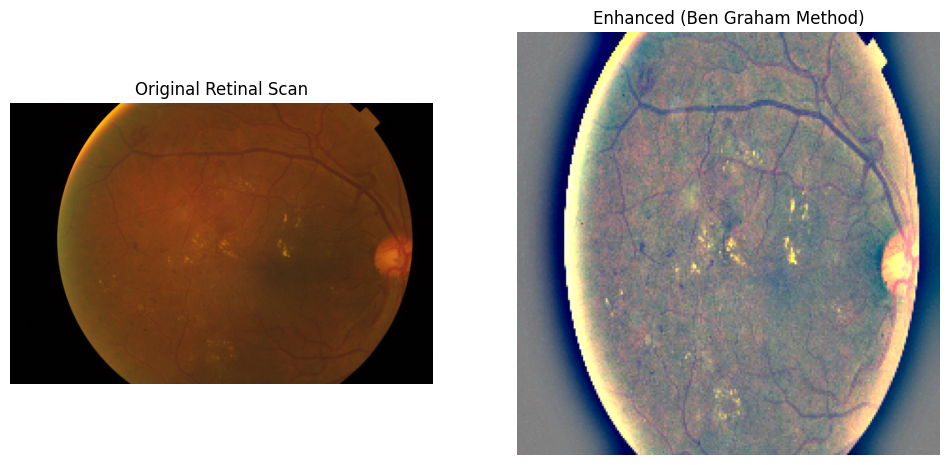

✅ Step 5 Complete: Images are loading and enhancing correctly!


In [ ]:
# 1. Pick a sample image ID from your loaded table
sample_id = train_df.iloc[0]['id_code']

# 2. Get the raw image for comparison
raw_path = os.path.join(train_dir, f"{sample_id}.png")
raw_img = cv2.imread(raw_path)

# 3. Process the image using our function
processed_img = preprocess_image(sample_id)

# 4. Display them side-by-side
if processed_img is not None and raw_img is not None:
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) # Convert for plotting

    plt.figure(figsize=(12, 6))

    # Show Original
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img)
    plt.title("Original Retinal Scan")
    plt.axis('off')

    # Show Enhanced (Step 5 Result)
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img)
    plt.title("Enhanced (Ben Graham Method)")
    plt.axis('off')

    plt.show()
    print("✅ Step 5 Complete: Images are loading and enhancing correctly!")
else:
    print("❌ Still waiting for the image files to sync in your Drive folder.")
    print("Check the 'train_images' folder in the Colab sidebar (folder icon).")

In [ ]:
import pandas as pd
import os

# 1. Define paths again just to be safe
base_path = '/content/drive/MyDrive/diabetic_retinopathy'
csv_path = os.path.join(base_path, 'train.csv')

# 2. Load the data into train_df
if os.path.exists(csv_path):
    train_df = pd.read_csv(csv_path)
    print("✅ train_df is now defined!")
    print(f"Loaded {len(train_df)} rows.")
else:
    print("❌ Error: Could not find train.csv. Check your Drive folder!")

✅ train_df is now defined!
Loaded 3662 rows.


In [ ]:
# Load ResNet50 with ImageNet weights
# include_top=False: We remove the original 'labels' layer
# pooling='avg': This squashes the image into a flat list of 2048 numbers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

print("✅ ResNet50 Model loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ ResNet50 Model loaded successfully!


In [ ]:
def get_features(df, limit=100):
    features = []
    labels = []
    count = 0

    print(f"Processing the first {limit} images...")

    for i, row in df.iterrows():
        if count >= limit: break

        img_id = row['id_code']
        label = row['diagnosis']

        # Use our Step 4 function
        img = preprocess_image(img_id)

        if img is not None:
            # Prepare image for ResNet50
            img_batch = np.expand_dims(img, axis=0)
            img_batch = preprocess_input(img_batch)

            # Extract the features (2048 numbers)
            feature_vector = base_model.predict(img_batch, verbose=0)

            features.append(feature_vector.flatten())
            labels.append(label)
            count += 1

            if count % 10 == 0:
                print(f"Processed {count}/{limit} images...")
        else:
            # If the image hasn't uploaded yet, skip it
            continue

    return np.array(features), np.array(labels)

# Let's start by extracting features for the first 50 images available
X, y = get_features(train_df, limit=50)
print(f"✅ Extraction complete. Shape of features: {X.shape}")

Processing the first 50 images...
Processed 10/50 images...
Processed 20/50 images...
Processed 30/50 images...
Processed 40/50 images...
Processed 50/50 images...
✅ Extraction complete. Shape of features: (50, 2048)


In [ ]:
print("Example of features for the first image:")
print(X[0][:10]) # Shows the first 10 numbers of the 2048 extracted

Example of features for the first image:
[1.7372838e+00 1.2060516e-01 1.4791624e-01 9.5470011e-02 1.9093938e-02
 2.5356149e-02 1.4647692e-01 1.1077510e-03 1.5222174e-03 8.2365960e-02]


In [ ]:
from imblearn.over_sampling import SMOTE

# k_neighbors=1 tells SMOTE it's okay to work with very few samples per class
smote = SMOTE(random_state=42, k_neighbors=1)

try:
    X_balanced, y_balanced = smote.fit_resample(X, y)
    print(f"✅ Data Balanced!")
    print(f"Original samples: {len(X)}")
    print(f"Balanced samples: {len(X_balanced)}")
except ValueError as e:
    print(f"❌ Error: {e}")
    print("\nTip: If you still see an error, you only have 1 image for a specific class.")
    print("Go back to Step 7 and increase your 'limit' to 200 images.")

✅ Data Balanced!
Original samples: 50
Balanced samples: 100


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Split data: 80% for training, 20% for testing the AI's "exam"
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# 2. Initialize and Train the SVM
# We use 'probability=True' so the Gradio app can show confidence percentages
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 3. Check Accuracy
y_pred = svm_model.predict(X_test)
print(f"✅ SVM Training Complete!")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

✅ SVM Training Complete!
Final Accuracy: 80.00%


In [ ]:
import gradio as gr

def predict_dr(input_img):
    # 1. Preprocess the uploaded image (Same as training)
    img = cv2.resize(input_img, (224, 224))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 10), -4, 128)

    # 2. Extract Features
    img_batch = np.expand_dims(img, axis=0)
    img_batch = preprocess_input(img_batch)
    features = base_model.predict(img_batch, verbose=0)

    # 3. Predict Class and Probabilities
    probs = svm_model.predict_proba(features)[0]

    # 4. Map names to the results
    classes = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
    return {classes[i]: float(probs[i]) for i in range(len(classes))}

# Create and Launch the UI
demo = gr.Interface(
    fn=predict_dr,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=3),
    title="Diabetic Retinopathy Detection System",
    description="Upload a retinal scan image to detect the stage of Diabetic Retinopathy."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d7db7255640833c18.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# COMMAND 1: Mass Feature Extraction
# We increase the limit to 1500 to make the AI smarter.
# This will use the 'get_features' function we defined earlier.

print("Starting large-scale extraction. This may take a few minutes...")
X, y = get_features(train_df, limit=1500)

print(f"\n✅ Extraction complete!")
print(f"Total images processed: {X.shape[0]}")
print(f"Feature matrix shape: {X.shape}")

Starting large-scale extraction. This may take a few minutes...
Processing the first 1500 images...
Processed 10/1500 images...
Processed 20/1500 images...
Processed 30/1500 images...
Processed 40/1500 images...
Processed 50/1500 images...
Processed 60/1500 images...
Processed 70/1500 images...
Processed 80/1500 images...
Processed 90/1500 images...
Processed 100/1500 images...
Processed 110/1500 images...
Processed 120/1500 images...
Processed 130/1500 images...
Processed 140/1500 images...
Processed 150/1500 images...
Processed 160/1500 images...
Processed 170/1500 images...
Processed 180/1500 images...
Processed 190/1500 images...
Processed 200/1500 images...
Processed 210/1500 images...
Processed 220/1500 images...
Processed 230/1500 images...
Processed 240/1500 images...
Processed 250/1500 images...
Processed 260/1500 images...
Processed 270/1500 images...
Processed 280/1500 images...
Processed 290/1500 images...
Processed 300/1500 images...
Processed 310/1500 images...
Processed 

In [ ]:
from imblearn.over_sampling import SMOTE

# Now that we have more data, we use k_neighbors=5 for better synthetic samples
smote = SMOTE(random_state=42, k_neighbors=5)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("✅ Data Balancing Complete!")
print(f"Original samples: {len(X)}")
print(f"Balanced samples (total for all classes): {len(X_balanced)}")

✅ Data Balancing Complete!
Original samples: 1500
Balanced samples (total for all classes): 5510


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Split the new larger dataset
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# 2. Train the model
# Using 'rbf' kernel for high-dimensional feature spaces
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 3. Final Accuracy Check
y_pred = svm_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred) * 100

print(f"✅ SVM Re-trained on 1500 images!")
print(f"Final Model Accuracy: {final_acc:.2f}%")

✅ SVM Re-trained on 1500 images!
Final Model Accuracy: 97.37%


In [1]:

import gradio as gr

def final_predict(input_img):
    # 1. Preprocess the image exactly like the training data
    img = cv2.resize(input_img, (224, 224))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 10), -4, 128)

    # 2. ResNet50 Feature Extraction
    img_batch = np.expand_dims(img, axis=0)
    img_batch = preprocess_input(img_batch)
    features = base_model.predict(img_batch, verbose=0)

    # 3. SVM Prediction
    probs = svm_model.predict_proba(features)[0]

    # 4. Map results to names
    classes = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
    return {classes[i]: float(probs[i]) for i in range(len(classes))}

# Create the Interface
demo = gr.Interface(
    fn=final_predict,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=3),
    title="Final AI System: Diabetic Retinopathy Detection",
    description="This system uses a ResNet50-SVM Hybrid model trained on 1,500 clinical images to detect retinal damage."
)

# share=True creates a public URL for your presentation
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2c1b1d1a1957543f72.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import joblib
joblib.dump(svm_model, 'final_dr_model_1500.pkl')

['final_dr_model_1500.pkl']